In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import umap
from spacy.lang.en import English
nlp = English(pipeline=[])
nlp.add_pipe("sentencizer")

In [25]:
tweets_df = pd.read_csv("data/trump_tweets.csv")

tweets_df["date"] = pd.to_datetime(tweets_df["date"])
tweets_df["isPresident"] = (
    tweets_df["date"].between(pd.to_datetime("2017-1-20"), pd.to_datetime("2021-1-20"))
) | (
    tweets_df["date"] > pd.to_datetime("2025-1-20")
)  # YMD format

tweets_df = tweets_df.sort_values(by="date")

# ---------------------------------------------------------------

obama_tweets_df = pd.read_csv("data/obama.csv")
obama_tweets_df["date"] = pd.to_datetime(obama_tweets_df["Timestamp"]).dt.tz_localize(
    None
)
obama_tweets_df["isPresident"] = obama_tweets_df["date"].between(
    pd.to_datetime("2009-1-20"), pd.to_datetime("2017-1-20")
)  # YMD format

obama_tweets_df = obama_tweets_df.sort_values(by="date")
obama_tweets_df.drop("Emojis", axis=1, inplace=True)

# ---------------------------------------------------------------

vix_df = pd.read_csv("data/VIX_DAILY.csv")
vix_df["observation_date"] = pd.to_datetime(vix_df["observation_date"])
returns = np.array(np.log(vix_df["VIXCLS"])[1:-1]) - np.array(
    np.log(vix_df["VIXCLS"])[:-2]
)
vix_df["return"] = np.pad(returns, (0, 2), mode="constant")  # add 0's at the end
vix_df["absreturn"] = np.abs(vix_df["return"])

vix_df = vix_df.sort_values("observation_date")

merged = pd.merge_asof(
    tweets_df, vix_df, left_on="date", right_on="observation_date", direction="backward"
)
merged.dropna(inplace=True)
merged_bama = pd.merge_asof(
    obama_tweets_df,
    vix_df,
    left_on="date",
    right_on="observation_date",
    direction="backward",
)
merged_bama.dropna(inplace=True)

In [35]:
merged.columns

Index(['id', 'text', 'isRetweet', 'isDeleted', 'device', 'favorites',
       'retweets', 'date', 'isFlagged', 'isPresident', 'observation_date',
       'VIXCLS', 'return', 'absreturn'],
      dtype='str')

In [83]:
merged

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,isPresident,observation_date,VIXCLS,return,absreturn
0,1698308935,Be sure to tune in and watch Donald Trump on L...,f,f,Twitter Web Client,939,519,2009-05-04 18:54:25,f,False,2009-05-04,34.53,-0.034471,0.034471
1,1701461182,Donald Trump will be appearing on The View tom...,f,f,Twitter Web Client,259,34,2009-05-05 01:00:10,f,False,2009-05-05,33.36,-0.027657,0.027657
2,1737479987,Donald Trump reads Top Ten Financial Tips on L...,f,f,Twitter Web Client,37,15,2009-05-08 13:38:08,f,False,2009-05-08,32.05,0.025263,0.025263
3,1741160716,New Blog Post: Celebrity Apprentice Finale and...,f,f,Twitter Web Client,29,11,2009-05-08 20:40:15,f,False,2009-05-08,32.05,0.025263,0.025263
4,1773561338,"""""""My persona will never be that of a wallflow...",f,f,Twitter Web Client,1877,1321,2009-05-12 14:07:28,f,False,2009-05-12,31.80,0.056547,0.056547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56566,1346928882595885058,https://t.co/Pm2PKV0Fp3,f,f,Twitter for iPhone,0,0,2021-01-06 21:17:24,f,True,2021-01-06,25.07,-0.113951,0.113951
56567,1346954970910707712,These are the things and events that happen wh...,f,f,Twitter for iPhone,0,0,2021-01-06 23:01:04,f,True,2021-01-06,25.07,-0.113951,0.113951
56568,1347334804052844550,https://t.co/csX07ZVWGe,f,f,Twitter Media Studio,629326,154877,2021-01-08 00:10:24,f,True,2021-01-08,21.56,0.110542,0.110542
56569,1347555316863553542,"The 75,000,000 great American Patriots who vot...",f,f,Twitter for iPhone,480997,108844,2021-01-08 14:46:38,f,True,2021-01-08,21.56,0.110542,0.110542


In [21]:
def tokenize(tweet):
    doc = nlp(str(tweet))
    tokens = []
    for sent in doc.sents:
        for token in sent:
            if not token.is_space:
                tokens.append(token.text.lower().strip())
        #print(sent)
    return tokens

In [12]:
tokenize("Alamaba is the best. Arkansas sucks!")

Alamaba is the best.
Arkansas sucks!


['alamaba', 'is', 'the', 'best', '.', 'arkansas', 'sucks', '!']

In [104]:
# Tokenize Data

trump_docs = [
    TaggedDocument(tokenize(doc), tags=[str(i)])
    for i, doc in enumerate(merged[merged["isPresident"]]["text"])
]
obama_docs = [
    TaggedDocument(tokenize(doc), tags=[str(i)])
    for i, doc in enumerate(merged_bama[merged_bama["isPresident"]]["Embedded_text"])
]

In [103]:
trump_space = Doc2Vec(trump_docs, min_count=5, epochs=5)
obama_space = Doc2Vec(obama_docs, min_count=5, epochs=5)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [105]:
trump_arr = np.array([trump_space.wv[id] for id in trump_space.wv.index_to_key])
obama_arr = np.array([obama_space.wv[id] for id in obama_space.wv.index_to_key])

In [106]:
trump_arr.shape
#len(trump_docs)

(6836, 100)

In [69]:
reducer = umap.UMAP(n_components=2)
obama_small = reducer.fit_transform(obama_arr)

reducer = umap.UMAP(n_components=2)
trump_small = reducer.fit_transform(trump_arr)

In [73]:
merged_bama.columns

Index(['UserScreenName', 'UserName', 'Timestamp', 'Text', 'Embedded_text',
       'Comments', 'Likes', 'Retweets', 'Image link', 'Tweet URL', 'date',
       'isPresident', 'observation_date', 'VIXCLS', 'return', 'absreturn'],
      dtype='str')

In [76]:
ldim_obama = pd.DataFrame(obama_small, columns=["x", "y"])
ldim_obama["VIX"] = merged_bama["VIXCLS"][merged_bama["isPresident"]]

ldim_trump = pd.DataFrame(trump_small, columns=["x", "y"])
ldim_trump["VIX"] = merged["VIXCLS"][merged["isPresident"]]

In [90]:
merged["VIXCLS"][merged["isPresident"] & merged["text"]]
ldim_trump

/var/folders/ql/3zwx504s3k1f_tq22crwym8r0000gq/T/ipykernel_72703/1170337152.py:1: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.


,x,y,VIX
0,14.535962,11.589813,NaN
1,14.348311,10.735292,NaN
2,14.160585,12.522387,NaN
3,14.610277,11.347713,NaN
4,14.343885,12.171726,NaN
...,...,...,...
6831,7.243950,12.232328,NaN
6832,5.554255,11.236043,NaN
6833,5.103155,12.597746,NaN
6834,5.539185,12.922109,NaN


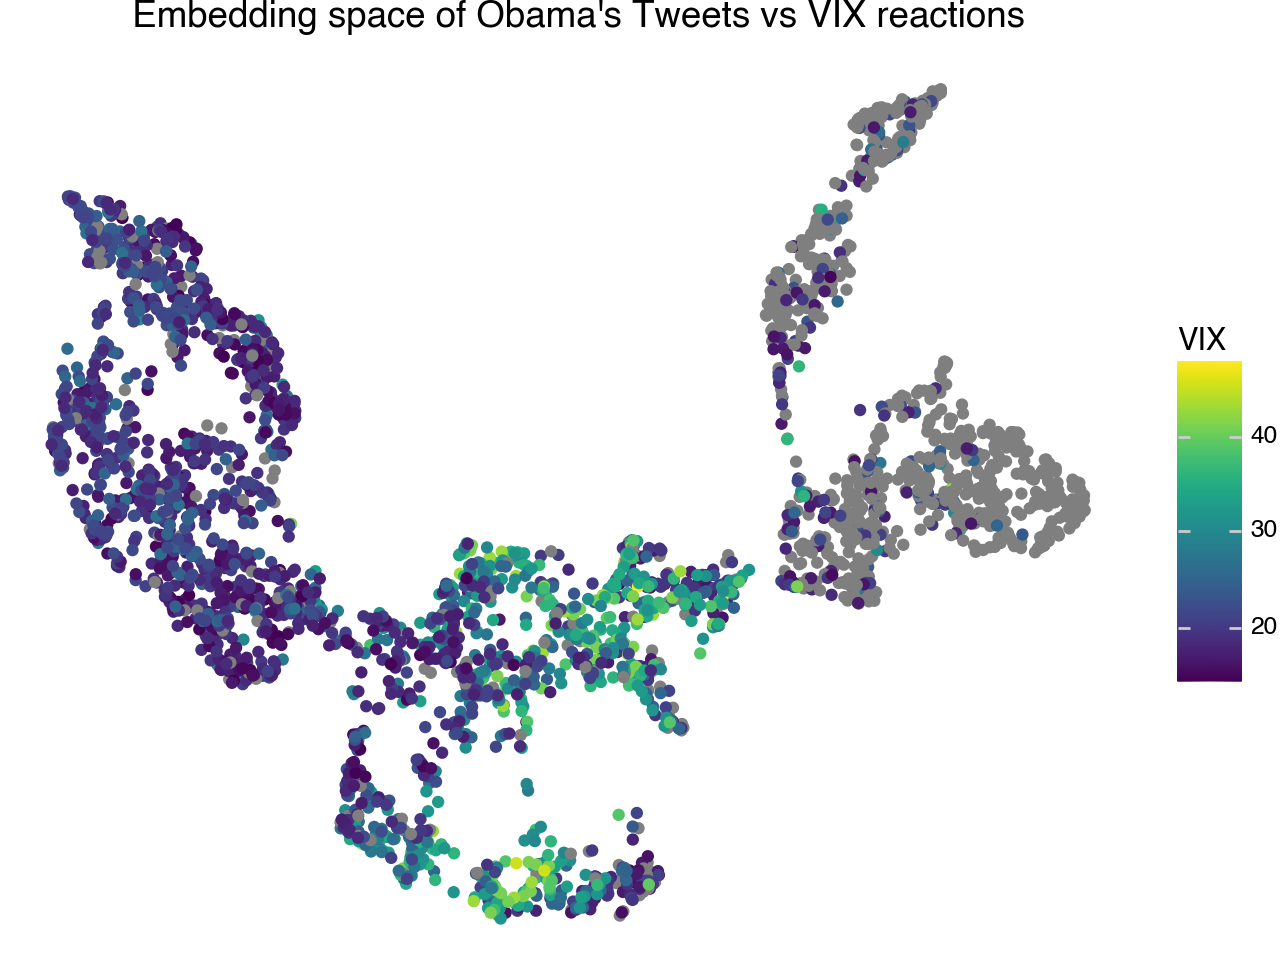

In [ ]:
from plotnine import ggplot, aes, geom_point, theme_void, labs

(ggplot(ldim_obama, aes(x="x", y="y", color="VIX")) + 
 geom_point() + 
 labs(title="Embedding space of Obama's Tweets vs VIX reactions") + 
 theme_void())

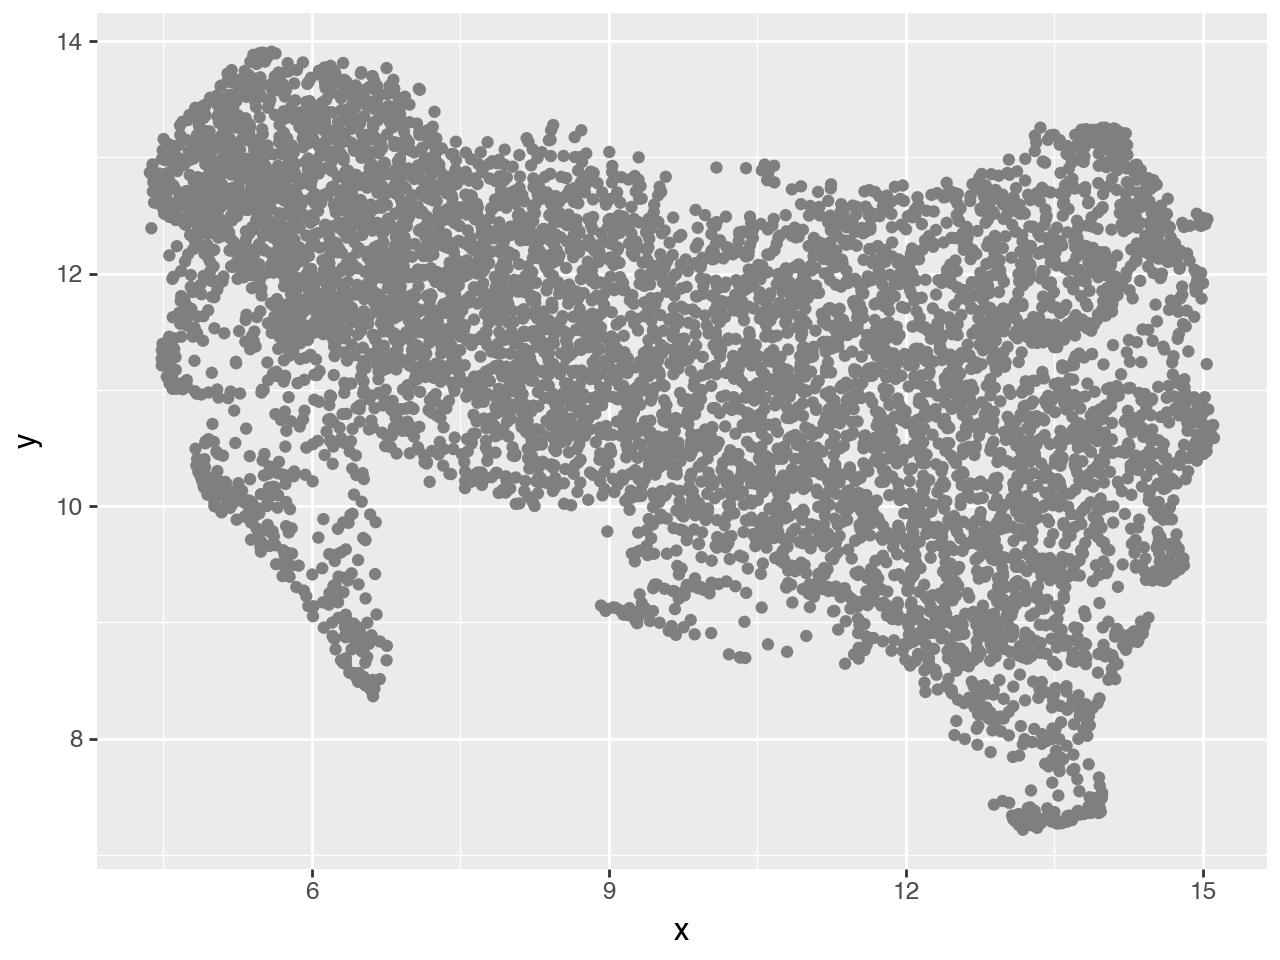

In [78]:
(ggplot(ldim_trump, aes(x="x", y="y", color="VIX")) + 
 geom_point())